In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from envs.so101_env import SO101Env
from PIL import Image
from IPython.display import display, clear_output
import cv2
import numpy as np
import time


%load_ext autoreload
%autoreload 2


In [2]:
env = SO101Env(
    task = "TableLegAssembleTask",
    obs_type = "pixels_agent_pos",
)

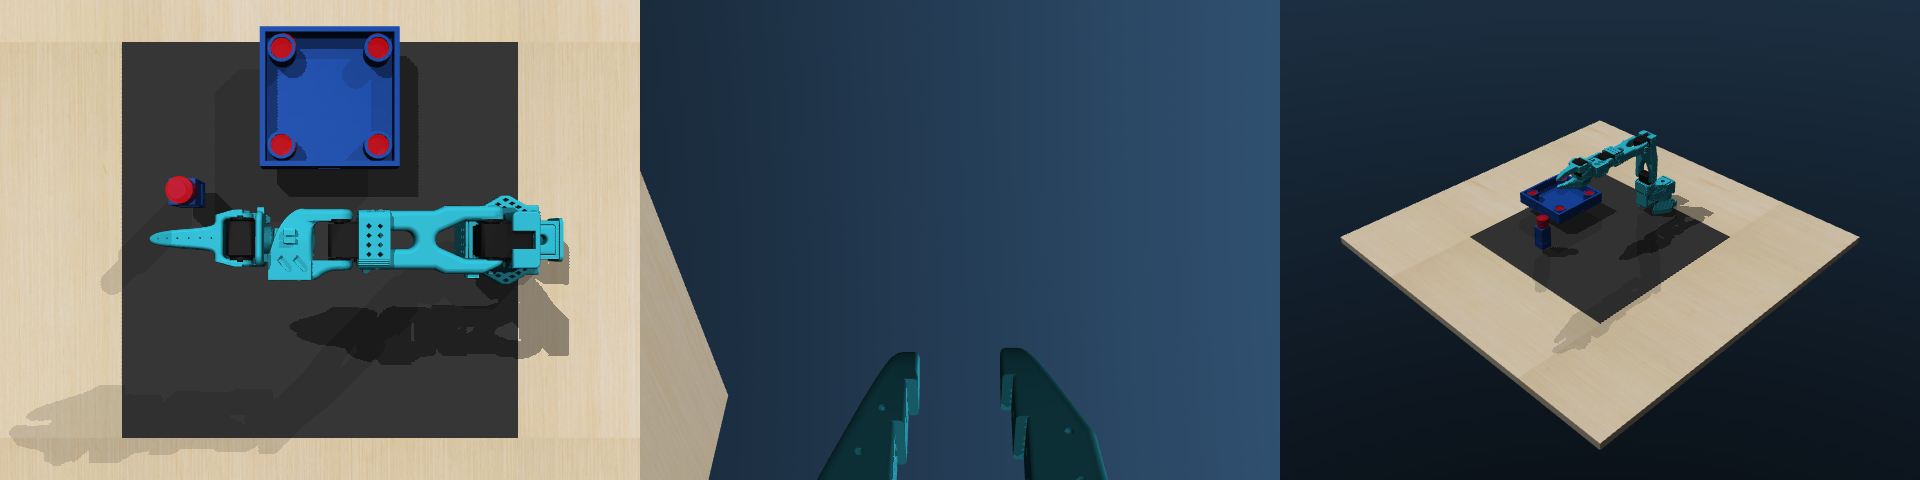

In [3]:
action = np.array([0]*6)

for _ in range(2):
    _, _, _, raw_obs = env._env.step(action)

    top = Image.fromarray(raw_obs["images"]["top_cam"])
    wrist = Image.fromarray(raw_obs["images"]["wrist_cam"])
    iso = Image.fromarray(raw_obs["images"]["iso_cam"])

    w, h = top.size
    combined = Image.new("RGB", (w * 3, h))
    combined.paste(top, (0, 0))
    combined.paste(wrist, (w, 0))
    combined.paste(iso, (2 * w, 0))

    clear_output(wait=True)
    display(combined)
    time.sleep(0.01)


In [4]:
raw_obs.keys()

odict_keys(['qpos', 'images'])

In [5]:
a, b = env.reset(seed = None)

In [6]:
a.keys()

dict_keys(['pixels', 'agent_pos'])

In [7]:
print("Bodies:")
for i in range(env._env.physics.model.nbody):
    print(f"{i}: {env._env.physics.model.id2name(i, 'body')}")

print("\nJoints:")
for i in range(env._env.physics.model.njnt):
    print(f"{i}: {env._env.physics.model.id2name(i, 'joint')}")


Bodies:
0: world
1: workspace
2: gray_mat
3: so101_root
4: base
5: shoulder
6: upper_arm
7: lower_arm
8: wrist
9: gripper
10: moving_jaw_so101_v1
11: table_leg
12: table_top

Joints:
0: shoulder_pan
1: shoulder_lift
2: elbow_flex
3: wrist_flex
4: wrist_roll
5: gripper
6: table_leg_joint
7: table_top_joint


In [8]:
a.keys()

dict_keys(['pixels', 'agent_pos'])

In [9]:
env.observation_space

Dict('pixels': Dict('top_cam': Box(0, 255, (480, 640, 3), uint8), 'wrist_cam': Box(0, 255, (480, 640, 3), uint8)), 'agent_pos': Box(-2.0, 2.0, (6,), float64))

In [10]:
env.action_space

Box(-2.0, 2.0, (6,), float32)

In [11]:
env.get_joint_range()

array([[-1.91986218,  1.91986218],
       [-1.74532925,  1.74532925],
       [-1.69      ,  1.69      ],
       [-1.65806285,  1.65806273],
       [-2.7438473 ,  2.84120631],
       [-0.17453298,  1.7453292 ]])

In [ ]:
from lerobot.scripts.rl.gym_manipulator import ConvertToLeRobotObservation, ResetWrapper, BatchCompatibleWrapper, TorchActionWrapper
wrapped_env = ConvertToLeRobotObservation(env, device = 'cuda')
wrapped_env = BatchCompatibleWrapper(wrapped_env)

In [28]:
a, b = wrapped_env.reset()

In [29]:
a.keys()

dict_keys(['observation.images.top_cam', 'observation.images.wrist_cam', 'observation.state'])

In [31]:
a['observation.images.top_cam'].shape

torch.Size([1, 3, 480, 640])

In [35]:
a['observation.state']

tensor([[0., 0., 0., 0., 0., 0.]], device='cuda:0')

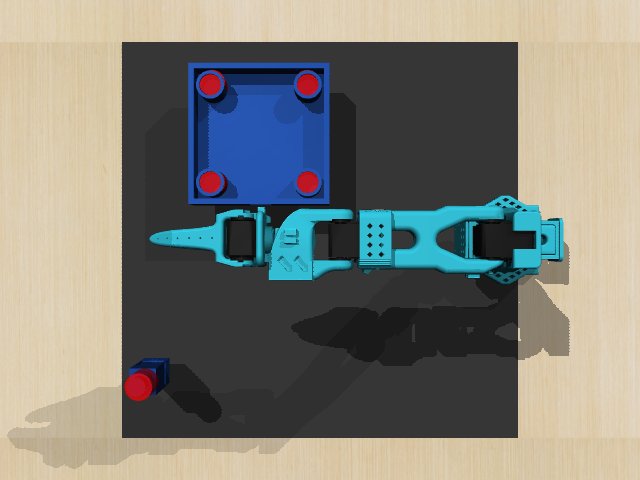

In [32]:
import torchvision.transforms.functional as TF

img_tensor = a['observation.images.top_cam'].squeeze(0)  # shape: (3, 480, 640)
img = TF.to_pil_image(img_tensor)
clear_output(wait=True)
display(img)

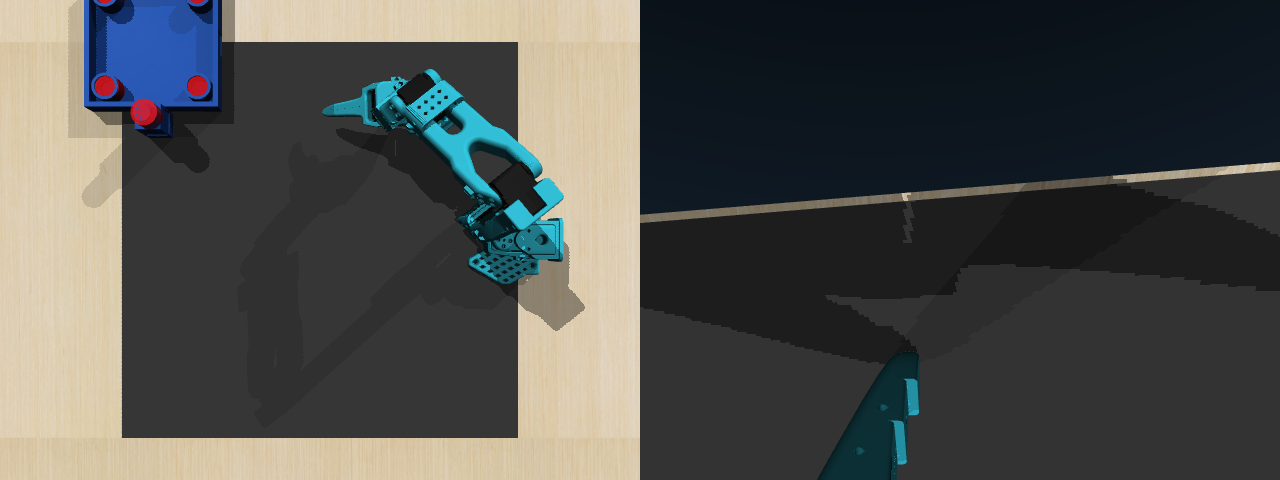

KeyboardInterrupt: 

In [42]:
wrapped_env.reset()
action = np.array([1]*6)

for _ in range(50):
    observation, reward, terminated, truncated, info = wrapped_env.step(action)

    top_tensor = observation['observation.images.top_cam']
    top_img = TF.to_pil_image(top_tensor.squeeze(0).cpu())  # shape (3, H, W)

    wrist_tensor = observation['observation.images.wrist_cam']
    wrist_img = TF.to_pil_image(wrist_tensor.squeeze(0).cpu())

    w, h = top.size
    combined = Image.new("RGB", (w * 2, h))
    combined.paste(top_img, (0, 0))
    combined.paste(wrist_img, (w, 0))

    clear_output(wait=True)
    display(combined)
    time.sleep(0.01)


In [43]:
observation.keys()

dict_keys(['observation.images.top_cam', 'observation.images.wrist_cam', 'observation.state'])